# 05 — Breach-Risk Classifier

**Layer:** Machine learning  
**Objective:** Predict whether a provider × specialty will **fail the 18-week standard next month** (`pct_within_18wk < 0.92`), and output a calibrated risk score.  
**Input:** `data/processed/rtt_features.parquet`.  
**Target:** `target_breach_next` (1 = next month breaches the standard).  
**Model:** XGBoost classifier.  
**Baselines:** majority class (always breach) and breach-persistence (next = current breach status).

**Class balance:** ~85% of provider-specialty-months breach, so accuracy is misleading (always-breach scores ~0.85). The model is judged primarily on **ROC AUC** and **PR AUC** — threshold-free measures of how well it *ranks* risk — since the deliverable is a risk score, not a single yes/no.

**Evaluation:** time-based split (train before Dec 2025; test Dec 2025–Feb 2026, predicting Jan–Mar 2026).

**Execution:** select the `Python (HCIP)` kernel, then run all cells in order.

## 1. Load, features, target

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, average_precision_score, accuracy_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve)
from xgboost import XGBClassifier


def resolve_dir(*parts: str) -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        candidate = base.joinpath(*parts)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not locate '{Path(*parts)}'.")


FEATURES_PATH = resolve_dir("data", "processed") / "rtt_features.parquet"
TARGET = "target_breach_next"
TEST_FROM = pd.Timestamp("2025-12-01")

FEATURE_COLS = [
    "total_waiting", "pct_within_18wk", "breach_rate", "over_52_share", "over_104_share",
    "month", "quarter", "month_sin", "month_cos",
    "lag1_total", "lag2_total", "lag3_total", "lag12_total", "lag1_breach", "lag12_breach",
    "roll3_total", "roll6_total", "roll12_total", "roll3_std_total",
    "mom_change_total", "mom_pct_total", "yoy_pct_total",
]

df = pd.read_parquet(FEATURES_PATH).dropna(subset=[TARGET, "pct_within_18wk"]).reset_index(drop=True)
df[TARGET] = df[TARGET].astype(int)
df["current_breach"] = (df["pct_within_18wk"] < 0.92).astype(int)
print(f"Rows: {len(df):,} | overall breach rate: {df[TARGET].mean():.3f}")

Rows: 81,751 | overall breach rate: 0.842


## 2. Time-based split

In [2]:
train = df[df["period_date"] < TEST_FROM]
test = df[df["period_date"] >= TEST_FROM]
y_test = test[TARGET].to_numpy()
print(f"Train: {len(train):,}  Test: {len(test):,}  (test breach rate {y_test.mean():.3f})")

Train: 71,103  Test: 10,648  (test breach rate 0.847)


## 3. Metric helper and baselines

ROC AUC and PR AUC use the score/probability (threshold-free); accuracy, precision, recall and F1 use a 0.5 cut.

In [3]:
def report(name: str, y_true, proba, label) -> dict:
    y_true = np.asarray(y_true)
    return {
        "model": name,
        "ROC_AUC": roc_auc_score(y_true, proba) if y_true.min() != y_true.max() else np.nan,
        "PR_AUC": average_precision_score(y_true, proba),
        "accuracy": accuracy_score(y_true, label),
        "precision": precision_score(y_true, label, zero_division=0),
        "recall": recall_score(y_true, label, zero_division=0),
        "F1": f1_score(y_true, label, zero_division=0),
    }


results = []
results.append(report("Majority (always breach)", y_test, np.ones_like(y_test, float), np.ones_like(y_test)))
current_breach = test["current_breach"].to_numpy()
results.append(report("Breach persistence (next=now)", y_test, current_breach.astype(float), current_breach))
pd.DataFrame(results).set_index("model").round(3)

,ROC_AUC,PR_AUC,accuracy,precision,recall,F1
model,,,,,,
Majority (always breach),0.500,0.847,0.847,0.847,1.000,0.917
Breach persistence (next=now),0.891,0.963,0.944,0.967,0.967,0.967


## 4. Train the XGBoost classifier

In [4]:
clf = XGBClassifier(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1,
    eval_metric="logloss",
)
clf.fit(train[FEATURE_COLS], train[TARGET])
proba = clf.predict_proba(test[FEATURE_COLS])[:, 1]
label = (proba >= 0.5).astype(int)
results.append(report("XGBoost", y_test, proba, label))
print("Trained.")

Trained.


## 5. Results

ROC AUC and PR AUC are the headline metrics (the deliverable is a risk score). Higher is better.

In [5]:
pd.DataFrame(results).set_index("model").round(3)

,ROC_AUC,PR_AUC,accuracy,precision,recall,F1
model,,,,,,
Majority (always breach),0.500,0.847,0.847,0.847,1.000,0.917
Breach persistence (next=now),0.891,0.963,0.944,0.967,0.967,0.967
XGBoost,0.978,0.996,0.944,0.968,0.966,0.967


## 6. Confusion matrix and ROC curve

Confusion matrix (rows = actual, cols = predicted):
                pred: meets  pred: breach
actual: meets          1336           291
actual: breach          310          8711


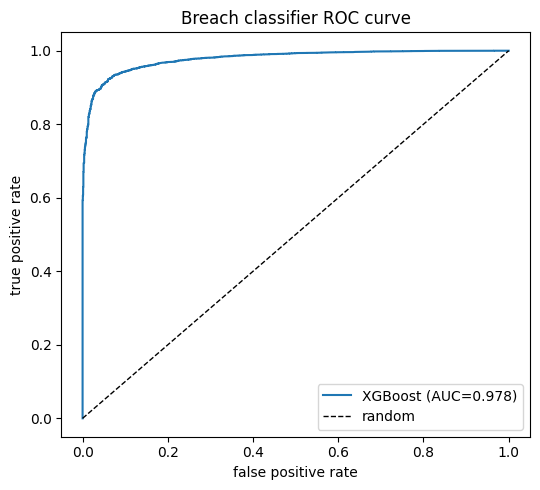

In [6]:
cm = confusion_matrix(y_test, label)
print("Confusion matrix (rows = actual, cols = predicted):")
print(pd.DataFrame(cm, index=["actual: meets", "actual: breach"], columns=["pred: meets", "pred: breach"]))

fpr, tpr, _ = roc_curve(y_test, proba)
plt.figure(figsize=(5.5, 5))
plt.plot(fpr, tpr, label=f"XGBoost (AUC={roc_auc_score(y_test, proba):.3f})")
plt.plot([0, 1], [0, 1], color="black", linewidth=1, linestyle="--", label="random")
plt.xlabel("false positive rate"); plt.ylabel("true positive rate")
plt.title("Breach classifier ROC curve"); plt.legend()
plt.tight_layout(); plt.show()

## 7. Feature importance and risk score

In [7]:
importance = pd.Series(clf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print("Top features:")
print(importance.head(10).round(3))

# Risk score 0-100, as specified by the architecture (POST /predict-breach-risk).
test_scored = test[["period_date", "provider_name", "specialty_name"]].copy()
test_scored["risk_score"] = (proba * 100).round(1)
test_scored["actual_breach"] = y_test
test_scored.sort_values("risk_score", ascending=False).head(10)

Top features:
pct_within_18wk    0.405
breach_rate        0.389
total_waiting      0.038
lag1_breach        0.021
roll3_total        0.020
lag1_total         0.010
roll12_total       0.010
roll6_total        0.009
over_52_share      0.008
lag12_breach       0.008
dtype: float32


,period_date,provider_name,specialty_name,risk_score,actual_breach
76,2026-01-01,BUCKSHAW HOSPITAL,General Surgery Service,100.0,1
81637,2026-02-01,FAIRFIELD INDEPENDENT HOSPITAL,Trauma and Orthopaedic Service,100.0,1
81636,2026-01-01,FAIRFIELD INDEPENDENT HOSPITAL,Trauma and Orthopaedic Service,100.0,1
81635,2025-12-01,FAIRFIELD INDEPENDENT HOSPITAL,Trauma and Orthopaedic Service,100.0,1
77,2026-02-01,BUCKSHAW HOSPITAL,General Surgery Service,100.0,1
57312,2025-12-01,THE DUDLEY GROUP NHS FOUNDATION TRUST,Dermatology Service,100.0,1
57313,2026-01-01,THE DUDLEY GROUP NHS FOUNDATION TRUST,Dermatology Service,100.0,1
57314,2026-02-01,THE DUDLEY GROUP NHS FOUNDATION TRUST,Dermatology Service,100.0,1
57358,2025-12-01,THE DUDLEY GROUP NHS FOUNDATION TRUST,Neurology Service,100.0,1
57359,2026-01-01,THE DUDLEY GROUP NHS FOUNDATION TRUST,Neurology Service,100.0,1


## 8. Findings

**Result (test: Jan–Mar 2026):**

| Model | ROC AUC | PR AUC | Accuracy | F1 |
|---|---|---|---|---|
| Majority (always breach) | 0.500 | 0.847 | 0.847 | 0.917 |
| Breach persistence (next = now) | 0.891 | 0.963 | 0.944 | 0.967 |
| **XGBoost** | **0.978** | **0.996** | 0.944 | 0.967 |

**Interpretation.** Unlike demand forecasting, breach risk has strong learnable signal. XGBoost lifts ROC AUC from the persistence baseline's 0.891 to **0.978** — a large improvement in its ability to *rank* which services are most at risk. Hard-label accuracy and F1 match persistence (~0.94 / 0.97) because the majority of services are persistently in breach and rarely flip state; the model's added value is in the **quality of the probability/risk score**, which is the actual deliverable (`POST /predict-breach-risk` → risk 0–100). The dominant features are current `pct_within_18wk` and `breach_rate`, with waiting-list volume and trend features providing the lift over persistence.

**Conclusion.** Adopt the XGBoost classifier as the breach-risk model and serve `predict_proba × 100` as the risk score. The decision threshold can be tuned to the operational need (e.g. lower it to catch more borderline services at the cost of more false alarms).

**Contrast with the demand model:** same data, same features, opposite outcome — demand level is near-random-walk (no ML gain), breach state is well-predicted (large ML gain). Choosing metrics per problem (MAE vs ROC/PR AUC) and baselining both is what surfaced the difference.